Purpose: Prediction + explainability
Sections:
🔹 Data Prep

In [6]:
import pandas as pd
import numpy as np

from sklearn.model_selection import train_test_split
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import classification_report, confusion_matrix, roc_auc_score
from sklearn.preprocessing import StandardScaler

import matplotlib.pyplot as plt
import seaborn as sns

# Load processed data
df = pd.read_csv("../data/processed/segmented_data.csv")

df.head()


df.shape
df.isnull().sum()
df["Churned"].value_counts(normalize=True)


Churned
0    0.711
1    0.289
Name: proportion, dtype: float64

3. Feature / Target Split

In [7]:
y = df["Churned"]
X = df.drop(columns=["Churned"])


🧼 4. Encoding Categorical Variables

In [8]:
X = pd.get_dummies(X, drop_first=True)


✂️ 5. Train-Test Split

In [9]:
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42, stratify=y
)


🤖 6. Model Training

In [10]:
model = RandomForestClassifier(
    n_estimators=200,
    random_state=42,
    class_weight="balanced"
)

model.fit(X_train, y_train)


,n_estimators,200
,criterion,'gini'
,max_depth,None
,min_samples_split,2
,min_samples_leaf,1
,min_weight_fraction_leaf,0.0
,max_features,'sqrt'
,max_leaf_nodes,None
,min_impurity_decrease,0.0
,bootstrap,True
,oob_score,False


📈 7. Predictions

In [11]:
# Class predictions
y_pred = model.predict(X_test)

# Probability predictions
y_prob = model.predict_proba(X_test)[:,1]


8. Model Evaluation

In [12]:
print("Classification Report:\n")
print(classification_report(y_test, y_pred))

print("ROC-AUC Score:", roc_auc_score(y_test, y_prob))


Classification Report:

              precision    recall  f1-score   support

           0       0.92      0.97      0.95      7110
           1       0.92      0.79      0.85      2890

    accuracy                           0.92     10000
   macro avg       0.92      0.88      0.90     10000
weighted avg       0.92      0.92      0.92     10000

ROC-AUC Score: 0.9251921364227


9. Confusion Matrix

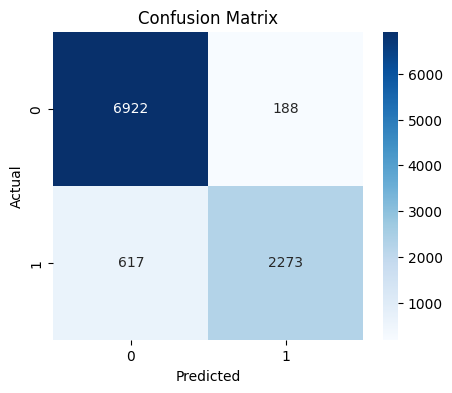

In [13]:
cm = confusion_matrix(y_test, y_pred)

plt.figure(figsize=(5,4))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.title("Confusion Matrix")
plt.show()


10. Feature Importance (Explainability)

In [14]:
feature_importance = pd.DataFrame({
    "feature": X.columns,
    "importance": model.feature_importances_
}).sort_values(by="importance", ascending=False)

feature_importance.head(20)


,feature,importance
13,Customer_Service_Calls,0.115207
18,Lifetime_Value,0.069123
21,risk_score,0.068795
5,Cart_Abandonment_Rate,0.066669
0,Age,0.065107
22,value_score,0.062851
20,engagement_index,0.052507
10,Discount_Usage_Rate,0.048101
12,Email_Open_Rate,0.035185
8,Average_Order_Value,0.033806


11. Feature Importance Visualization

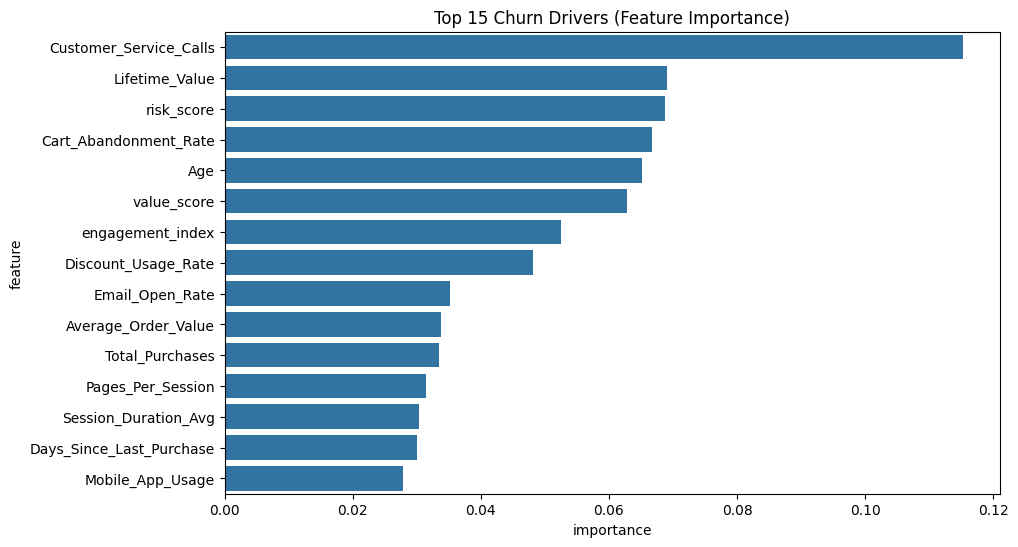

In [15]:
plt.figure(figsize=(10,6))
sns.barplot(
    x="importance",
    y="feature",
    data=feature_importance.head(15)
)
plt.title("Top 15 Churn Drivers (Feature Importance)")
plt.show()


12. Prediction Output Table (Business Layer)

In [16]:
pred_df = pd.DataFrame({
    "actual_churn": y_test.values,
    "predicted_churn": y_pred,
    "churn_probability": y_prob
})

pred_df.head(10)


,actual_churn,predicted_churn,churn_probability
0,0,0,0.080
1,0,0,0.025
2,0,0,0.210
3,0,0,0.045
4,0,0,0.065
5,0,0,0.090
6,0,0,0.045
7,0,0,0.060
8,0,0,0.085
9,1,1,0.790


13. Risk Bucketing (Business Intelligence)

In [17]:
def risk_bucket(p):
    if p >= 0.7:
        return "High Risk"
    elif p >= 0.4:
        return "Medium Risk"
    else:
        return "Low Risk"

pred_df["risk_bucket"] = pred_df["churn_probability"].apply(risk_bucket)

pred_df.head(10)


,actual_churn,predicted_churn,churn_probability,risk_bucket
0,0,0,0.080,Low Risk
1,0,0,0.025,Low Risk
2,0,0,0.210,Low Risk
3,0,0,0.045,Low Risk
4,0,0,0.065,Low Risk
5,0,0,0.090,Low Risk
6,0,0,0.045,Low Risk
7,0,0,0.060,Low Risk
8,0,0,0.085,Low Risk
9,1,1,0.790,High Risk


14. Risk Distribution

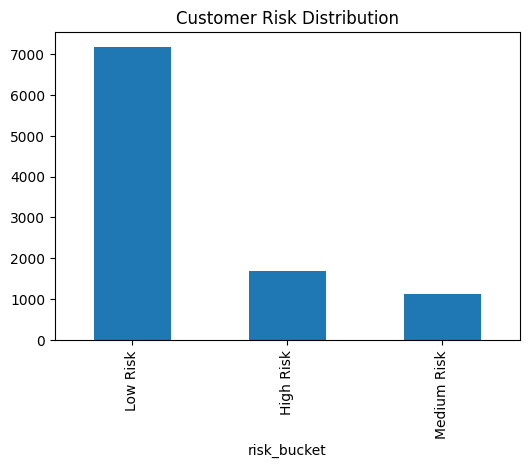

In [18]:
pred_df["risk_bucket"].value_counts().plot(
    kind="bar",
    title="Customer Risk Distribution",
    figsize=(6,4)
)
plt.show()


15. Revenue at Risk (Business Metric)

In [19]:
# Merge predictions back to customer data
risk_df = X_test.copy()
risk_df["churn_probability"] = y_prob
risk_df["risk_bucket"] = pred_df["risk_bucket"].values

# Recover Lifetime Value column
risk_df["Lifetime_Value"] = df.loc[X_test.index, "Lifetime_Value"].values

revenue_at_risk = risk_df[risk_df["risk_bucket"]=="High Risk"]["Lifetime_Value"].sum()

print("Revenue at Risk from High Risk Customers:", revenue_at_risk)


Revenue at Risk from High Risk Customers: 2687811.46


16. Save Predictions for Dashboard

In [20]:
pred_df.to_csv("../data/processed/churn_predictions.csv", index=False)
print("Saved: data/processed/churn_predictions.csv")


Saved: data/processed/churn_predictions.csv


17. Business Interpretation (Markdown Cell)
## Key Business Outputs

### High Risk Customers
Customers with churn probability > 0.7 are classified as high risk and should be prioritized for retention.

### Revenue at Risk
The system estimates potential revenue loss from high-risk customers using Lifetime Value.

### Key Churn Drivers
Feature importance analysis highlights behavioral, engagement, and service factors as primary churn drivers.

### Strategic Value
This model enables proactive retention instead of reactive churn handling.
